## Set up data and model objects

In [1]:
import pandas as pd
import numpy as np
import os

import mudata as md
import anndata as ad
import perturbo
import seaborn as sns
import pyro
from scipy.stats import norm
import matplotlib.pyplot as plt
import torch

torch.cuda.device_count()

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


0

In [2]:
import scvi
scvi.settings.seed = 0 

Global seed set to 0


Set training configuration and access to data

In [3]:
# data_dir = "/data/pinello/SHARED_DATA/gasperini_2019"
# data_dir = "/work/data/SHARED_DATA/gasperini_2019"
data_dir = "../../../Data/gasperini_pilot/"
batch_size=4096 # multiple of 64

# smoke_test=True # only run a tiny subset of genes
smoke_test=False # run full analysis

if torch.cuda.is_available():
    accelerator = "gpu"
    print("training using GPU")
else:
    accelerator = "cpu"
    print("training using CPU")

if smoke_test:
    selected_guides = ["TMED10_TSS|1", "TMED10_TSS|2"]
    selected_genes = ["ACTG1"]
else:
    selected_guides = None
    selected_genes = None


training using CPU


### Load the data
(50k cells, takes ~30 seconds)

In [4]:
mdata = md.read_h5mu(f'{data_dir}/gasperini_pilot_highMOI.h5mu')
# batch_size=None
mdata

MuData object with n_obs × n_vars = 47964 × 19482
  2 modalities
    rna:	47964 x 16367
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 3115
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [5]:
# mdata['grna'].varm['element_targeted']
mdata['grna'].varm['element_targeted']

,ACTB_TSS,ACTG1_TSS,ACYP1_TSS,ADIPOR1_TSS,ALDH1A2_TSS,APEX1_TSS,APLP2_TSS,ARF6_TSS,ARID1A_TSS,ARL4A_TSS,...,scrambled_24,scrambled_25,scrambled_2,scrambled_3,scrambled_4,scrambled_5,scrambled_6,scrambled_7,scrambled_8,scrambled_9
ACTB_TSS|1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTB_TSS|2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1_TSS|1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scrambled_7|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
scrambled_8|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
scrambled_8|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
scrambled_9|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [6]:
# from scipy import sparse


# print(mdata['rna'].varm['element_tested'].values.shape)
# print(mdata['grna'].varm['element_targeted'].values.shape)
# guide_tested = mdata['grna'].varm['element_targeted'].values @ mdata['rna'].varm['element_tested'].values.T

# # sparse_tested._nnz()
# # sparse_tested.indices()
# # sparse_tested.values().shape
# sparse_tested = torch.tensor(guide_tested).to_sparse()
# sparse_tested.sum() / (sparse_tested.shape[0] * sparse_tested.shape[0])

In [7]:
sceptre_df = pd.read_csv(f"{data_dir}/sceptre_results-2023_01_13.csv")
sceptre_df = sceptre_df.rename(columns={"gRNA_id": "guide", "gene_id": "gene", "z_value":"SCEPTRE_z_value","p_value":"SCEPTRE_p_value"})
sceptre_df


,gene,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change
0,Y_RNA,ACTB_TSS|1,positive_control,0.940707,1.632176,0.469126
1,FOXK1,ACTB_TSS|1,positive_control,0.153629,-0.992648,-0.088097
2,AP5Z1,ACTB_TSS|1,positive_control,0.123562,-1.010549,-0.119240
3,RADIL,ACTB_TSS|1,positive_control,0.057483,-1.501497,-0.386814
4,RNF216P1,ACTB_TSS|1,positive_control,0.341734,-0.635756,-0.034944
...,...,...,...,...,...,...
22261,SNORD60,scrambled_9|2,negative_control,0.950426,1.765242,0.708387
22262,DCAKD,scrambled_9|2,negative_control,0.488787,-0.149950,-0.027133
22263,RNF213-AS1,scrambled_9|2,negative_control,0.847978,1.018406,0.507472
22264,NAPB,scrambled_9|2,negative_control,0.696904,0.508168,0.149431


In [8]:
if not smoke_test or selected_genes is None:
    selected_genes = sceptre_df["gene"].unique()
if not smoke_test or selected_guides is None:
    selected_guides = sceptre_df["guide"].unique()

print(len(selected_genes), len(selected_guides))
# sceptre_df.query("guide=='GATA2_TSS|1'")


5859 1243


In [9]:
np.where(mdata['grna'][:,"scrambled_9|2"].varm["element_targeted"].values)
mdata['grna'][:,"scrambled_9|2"].varm["element_targeted"].columns[1560]

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


'scrambled_9'

In [10]:
sceptre_df.query("pair_type=='negative_control'")

,gene,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change
21272,Metazoa_SRP,random_1|1,negative_control,0.225595,-0.745345,-0.331922
21273,OR2G6,random_1|1,negative_control,0.985559,2.585539,0.942606
21274,SLC3A2,random_1|1,negative_control,0.874096,1.930871,0.153495
21275,PTPN11,random_1|1,negative_control,0.685826,0.454581,0.040252
21276,CORO7,random_1|1,negative_control,0.847094,1.114626,0.175454
...,...,...,...,...,...,...
22261,SNORD60,scrambled_9|2,negative_control,0.950426,1.765242,0.708387
22262,DCAKD,scrambled_9|2,negative_control,0.488787,-0.149950,-0.027133
22263,RNF213-AS1,scrambled_9|2,negative_control,0.847978,1.018406,0.507472
22264,NAPB,scrambled_9|2,negative_control,0.696904,0.508168,0.149431


In [11]:
grna_subset = mdata.mod['grna'][:,selected_guides]
rna_subset = mdata.mod['rna'][:,selected_genes]
mdata = md.MuData({'rna':rna_subset, 'grna':grna_subset}).copy()
mdata

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


MuData object with n_obs × n_vars = 47964 × 7102
  2 modalities
    rna:	47964 x 5859
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 1243
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [12]:
mdata['grna'].varm['element_targeted']

,ACTB_TSS,ACTG1_TSS,ACYP1_TSS,ADIPOR1_TSS,ALDH1A2_TSS,APEX1_TSS,APLP2_TSS,ARF6_TSS,ARID1A_TSS,ARL4A_TSS,...,scrambled_24,scrambled_25,scrambled_2,scrambled_3,scrambled_4,scrambled_5,scrambled_6,scrambled_7,scrambled_8,scrambled_9
ACTB_TSS|1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTB_TSS|2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1_TSS|1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scrambled_7|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
scrambled_8|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
scrambled_8|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
scrambled_9|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Register data with perturbo

In [13]:
# element_names1 = model.adata_manager.get_state_registry("tested_elements")['column_names']
# element_names2 = model.adata_manager.get_state_registry("targeted_elements")['column_names']
# assert element_names1 == element_names2

In [14]:
# %pip install scikit-misc

In [15]:
# sc.pp.highly_variable_genes(mdata['rna'], flavor='seurat_v3', batch_key="bath_number", n_top_genes=1000)
# # sc.pp.neighbors(mdata['rna'])
# sc.tl.pca(mdata['rna'])


In [16]:
mdata['rna'].obs

,bath_number,percent_mito,log_number_of_detected_genes,log_total_gene_count,log_total_guide_count,library_size
TTGAACGCAAGCGAGT,6,0.029057,8.385489,8.385717,7.330405,20602.0
ATTACTCGTGGTAACG,1,0.025976,8.254529,8.254789,5.986452,14048.0
GTAGTCATCGTTGACA,5,0.042747,8.206584,8.206856,5.225747,13701.0
GTGTGCGTCCCGACTT,4,0.042587,8.327726,8.327968,5.700444,17474.0
GCATGCGAGAAACGAG,3,0.021318,7.806289,7.806696,7.071573,8807.0
...,...,...,...,...,...,...
GGAATAATCTGGGCCA,3,0.091893,8.316056,8.316300,5.793014,15244.0
GTCCTCATCTTGTATC,6,0.043563,7.293698,7.294377,6.093570,3588.0
CCACTACGTAGAGCTG,6,0.021208,8.134761,8.135054,6.400258,12897.0
CGTTCTGAGGATGGTC,6,0.025178,8.203851,8.204125,5.730100,13752.0


In [17]:
mdata[mdata['rna'].obs['percent_mito']<0.1,:]

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


View of MuData object with n_obs × n_vars = 47679 × 7102
  2 modalities
    rna:	47679 x 5859
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47679 x 1243
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:315: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(adata.obs[key]):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/scanpy/plotting/_utils.py:714: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


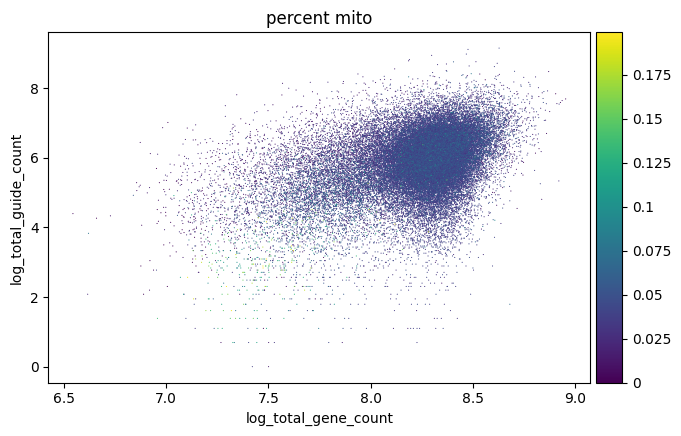

In [18]:
# mdata.update()
import scanpy as sc

# mdata = mdata[mdata['rna'].obs['percent_mito']<0.1,:].copy()
sc.pl.scatter(mdata['rna'],"log_total_gene_count", "log_total_guide_count", "percent_mito")
# mdata

In [19]:
# sc.pl.pca(mdata['rna'], color="bath_number")
# sc.pl.pca(mdata['rna'], color="percent_mito")


In [20]:
perturbo.PERTURBO.setup_mudata(
    mdata,
    batch_key="bath_number",
    library_size_key="library_size",
    continuous_covariates_keys=["log_total_guide_count", "percent_mito"],
    # var_by_element_key="element_tested",
    guide_by_element_key="element_targeted",
    gene_by_element_key="element_tested",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model = perturbo.PERTURBO(mdata, likelihood="nb", n_factors=None)
model.view_anndata_setup()


INFO     Using column names from columns of adata.varm['element_tested']                                           
INFO     Using column names from columns of adata.varm['element_targeted']                                         


Anndata setup with scvi-tools version 1.0.3.

Setup via `PERTURBO.setup_anndata` with arguments:

{
│   'rna_layer': None,
│   'perturbation_layer': None,
│   'batch_key': 'bath_number',
│   'gene_by_element_key': 'element_tested',
│   'rna_element_uns_key': None,
│   'guide_element_uns_key': None,
│   'guide_by_element_key': 'element_targeted',
│   'library_size_key': 'library_size',
│   'size_factor_key': None,
│   'continuous_covariates_keys': ['log_total_guide_count', 'percent_mito'],
│   'categorical_covariates_keys': None,
│   'modalities': {'rna_layer': 'rna', 'perturbation_layer': 'grna'}
}

        Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch         │   6   │
│         n_cells         │ 47964 │
│ n_extra_continuous_covs │   2   │
│     n_perturbations     │ 1243  │
│   n_targeted_elements   │ 1561  │
│    n_tested_elements    │ 1561  │
│         n_vars          │ 5859  │
└─────────────────────────┴───────┘

                                 Data Registry                                  
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃                 scvi-tools Location                  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.mod['rna'].X                  │
│         batch         │         adata.mod['rna'].obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.mod['rna'].obsm['_scvi_extra_continuous_covs'] │
│         ind_x         │            adata.mod['rna'].obs['_ind_x']            │
│     perturbations     │                 adata.mod['grna'].X                  │
│      size_factor      │         adata.mod['rna'].obs['_size_factor']         │
│   targeted_elements   │      adata.mod['grna'].varm['element_targeted']      │
│    tested_elements    │       adata.mod['rna'].varm['element_tested']        │
└───────────────────────┴──────────────────────────────────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['bath_number'] │     1      │          0          │
│                          │     2      │          1          │
│                          │     3      │          2          │
│                          │     4      │          3          │
│                          │     5      │          4          │
│                          │     6      │          5          │
└──────────────────────────┴────────────┴─────────────────────┘

 extra_continuous_covs State Registry 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃          Source Location           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['log_total_guide_count'] │
│     adata.obs['percent_mito']      │
└────────────────────────────────────┘

### Train the model

In [21]:
list(pyro.get_param_store().keys())

[]

In [22]:
# burn-in
pyro.clear_param_store()
# plan_kwargs = {'optim': pyro.optim.ClippedAdam(dict(lr=0.1, lrd=0.96))}
# model.train(20, lr=0.05, batch_size=512, use_gpu=use_gpu)
# model.train(20, lr=0.05, batch_size=512, use_gpu=use_gpu)


In [23]:
# len(mdata['rna'])/batch_size
# # 0.9**(1/11)


In [24]:
# from pyro.optim import ClippedAdam
from torch.optim import Adam
from pyro.infer import TraceMeanField_ELBO
from math import ceil

optimizer = Adam
steps_per_epoch = ceil(model.module.n_cells / batch_size)
# scheduler = pyro.optim.MultiStepLR(
#     {
#         "optimizer": optimizer,
#         "optim_args": {"lr": 0.1},
#         "gamma": 0.3,
#         # "milestones": [steps_per_epoch * 10, steps_per_epoch*20],
#         "milestones": [10, 20],
#     }
# )

# scheduler = pyro.optim.ReduceLROnPlateau(
#     {
#         "optimizer": optimizer,
#         "optim_args": {"lr": 0.1},
#         "threshold": 1e-2,
#         "patience": 5,
#         "factor": 0.3,
#     }
# )

model.train(
    15,
    lr=0.01,
    # plan_kwargs={"optim": scheduler},
    batch_size=128,
    accelerator=accelerator,
)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
/Users/ljb80/Projects/perturbo/src/perturbo/_module.py:216: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:56.)
  total_perturbation_effect = guide_efficacy @ element_local_effec

Epoch 15/15: 100%|██████████| 15/15 [09:03<00:00, 36.55s/it, v_num=1, elbo_train=2.19e+8]

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 15/15: 100%|██████████| 15/15 [09:03<00:00, 36.25s/it, v_num=1, elbo_train=2.19e+8]


In [25]:
model.train(
    15,
    lr=0.001,
    # plan_kwargs={"optim": scheduler},
    batch_size=512,
    accelerator=accelerator,
)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 15/15: 100%|██████████| 15/15 [04:25<00:00, 17.71s/it, v_num=1, elbo_train=2.18e+8]

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 15/15: 100%|██████████| 15/15 [04:25<00:00, 17.72s/it, v_num=1, elbo_train=2.18e+8]


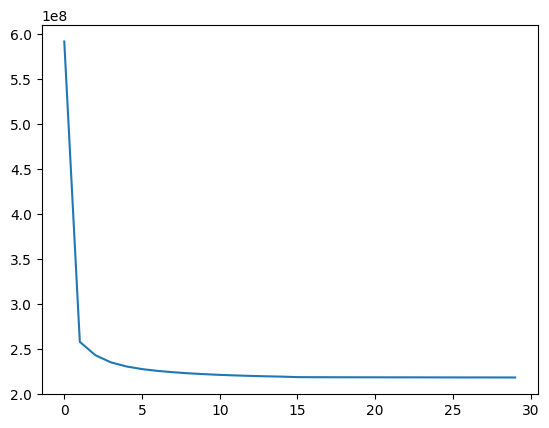

In [26]:
plt.plot(model.history["elbo_train"])


In [27]:

# model.train(
#     20, plan_kwargs={"loss_fn": TraceMeanField_ELBO()}, batch_size=2048, accelerator=accelerator
# )
model.history.keys()

dict_keys(['elbo_train'])

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
          1.,   2.,   2.,   1.,   2.,   4.,   3.,   2.,   4.,   6.,   2.,
          7.,   2.,   2.,   7.,   4.,   7.,   6.,   7.,   4.,   5.,   7.,
         17.,  10.,  13.,  15.,   7.,  11.,  10.,  16.,  19.,  12.,  23.,
         18.,  23.,  31.,  30.,  30.,  34.,  35.,  27.,  40.,  50.,  57.,
         47.,  49.,  52.,  47.,  63.,  59.,  67.,  72.,  67.,  66.,  76.,
        102.,  91., 111., 108., 100., 111., 134., 139., 150., 140., 160.,
        176., 180., 206., 198., 236., 275., 272., 293., 303., 327., 340.,
        380., 388., 396., 443., 446., 493., 465., 459., 461., 361., 205.,
         69.]),
 array([0.12803517, 0.1367308 , 0.14542644, 0.15412207, 0.1628177 ,
        0.17151333, 0.18020897, 0.1889046 , 0.19760023, 0.20629587,
        0.2149915 , 0.22368713, 0.23238276, 0.2410784 , 0.24977403,
        0.25846966, 0.2671653 , 0.27586093, 0.28455656, 0.29325219,
        0.30194783, 0.31064346, 0.31933909, 0.

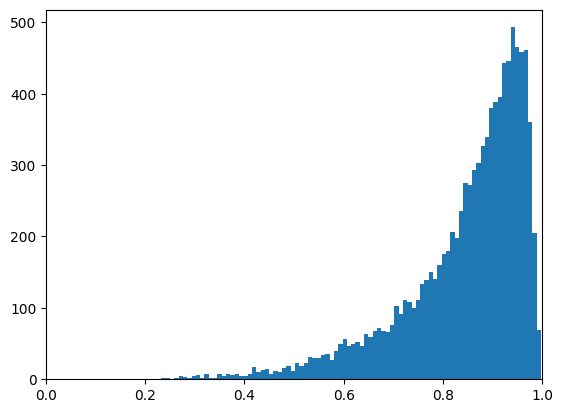

In [28]:
# logit normal prior plot
import numpy as np
x = np.random.normal(loc=2, scale=1, size=10000)
plt.xlim(0,1)
xsigmoid = 1/(1+np.exp(-x))
plt.hist(xsigmoid, bins=100)

In [29]:
# model.render_guide()
# loc, scale = model.module.guide._get_loc_and_scale("perturb_mean_lfc")
# loc.max()

In [30]:
# model.module.guide.quantiles([0.05,0.5,0.95])["element_mean_pooling"]

In [31]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)
    if sum(v.shape) <= 1:
        print(v)

AutoNormal.locs.element_effects torch.Size([24431])
AutoNormal.scales.element_effects torch.Size([24431])
AutoNormal.locs.guide_efficacy torch.Size([1243, 1])
AutoNormal.scales.guide_efficacy torch.Size([1243, 1])
AutoNormal.locs.log_gene_mean torch.Size([5859])
AutoNormal.scales.log_gene_mean torch.Size([5859])
AutoNormal.locs.log_gene_dispersion torch.Size([5859])
AutoNormal.scales.log_gene_dispersion torch.Size([5859])
AutoNormal.locs.batch_effect torch.Size([6, 5859])
AutoNormal.scales.batch_effect torch.Size([6, 5859])
AutoNormal.locs.batch_disp_effect torch.Size([6, 5859])
AutoNormal.scales.batch_disp_effect torch.Size([6, 5859])
AutoNormal.locs.cont_covariate_effect torch.Size([3, 5859])
AutoNormal.scales.cont_covariate_effect torch.Size([3, 5859])
AutoNormal.locs.cont_covariate_disp_effect torch.Size([3, 5859])
AutoNormal.scales.cont_covariate_disp_effect torch.Size([3, 5859])
perturbo$$$_guide.locs.element_effects_unconstrained torch.Size([24431])
perturbo$$$_guide.locs.guide_

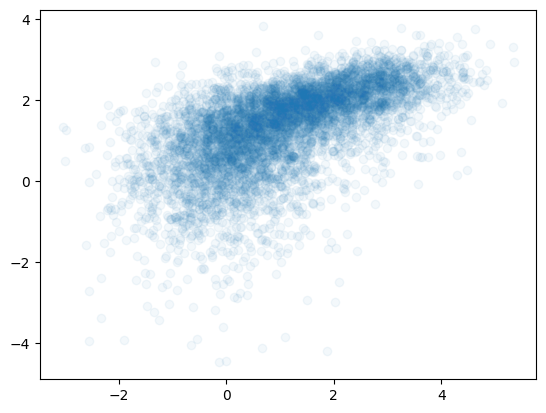

In [32]:
mean = model.module.guide.median()['log_gene_mean'].numpy()
dispersion = model.module.guide.median()['log_gene_dispersion'].numpy()
plt.scatter(mean, dispersion, alpha=0.05)


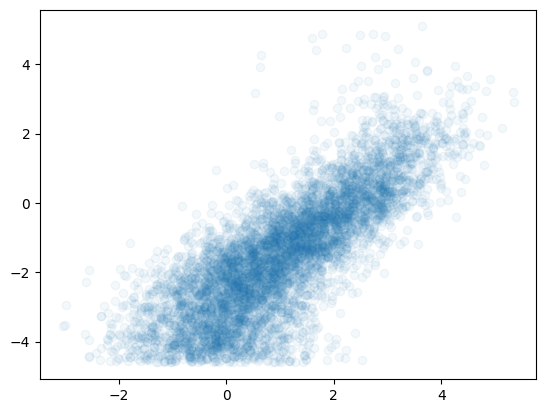

In [33]:
plt.scatter(mean, np.log(mdata['rna'].X.mean(axis=0).A1), alpha=0.05)


In [34]:
from scipy.sparse import coo_matrix, issparse

loc1_values, scale1_values = model.module.guide._get_loc_and_scale("element_effects")
i1, j1 = model.module.element_by_gene_idx.detach().cpu().numpy().astype(int)

element_ids = model.adata_manager.get_state_registry("tested_elements").column_names
gene_ids = model.adata_manager.get_state_registry("X").column_names
pert_ids = model.adata_manager.get_state_registry("perturbations").column_names
element_effects = pd.DataFrame(
    {
        "loc": loc1_values.detach(),
        "scale": scale1_values.detach(),
        "element": [element_ids[idx] for idx in i1],
        "gene": [gene_ids[idx] for idx in j1],
    }
).assign(
    z_value=lambda x: x["loc"] / x["scale"],
    p_value=lambda x: norm.cdf(x['z_value']),
    is_target=lambda x: x['element'].str.split('_', expand=True)[0] == x['gene']
)

element_effects.sort_values("z_value")

,loc,scale,element,gene,z_value,p_value,is_target
5050,-2.338110,0.035746,RPL29_TSS,RPL29,-65.409454,0.0,True
1265,-2.615915,0.042140,CUTA_TSS,CUTA,-62.076561,0.0,True
483,-1.494630,0.025809,BTF3_TSS,BTF3,-57.910145,0.0,True
1223,-2.896356,0.050403,CSTB_TSS,CSTB,-57.463600,0.0,True
6252,-2.895871,0.051288,TSPO_TSS,TSPO,-56.462757,0.0,True
...,...,...,...,...,...,...,...
8417,1.222558,0.163350,chr11:64102407-64102430,PRDX5,7.484291,1.0,False
9380,1.740041,0.229974,chr12:121566625-121566648,KNTC1,7.566245,1.0,False
3681,2.733281,0.277462,NDUFV2_TSS,NDUFV2-AS1,9.851024,1.0,False
5828,2.761964,0.155085,TFRC_TSS,LINC00885,17.809345,1.0,False


<Axes: >

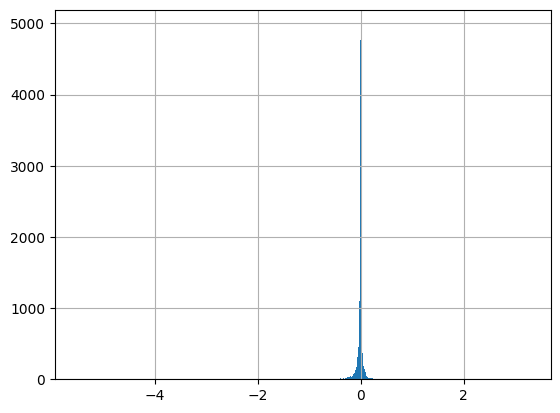

In [35]:
element_effects['loc'].hist(bins=1000)
# plt.semilogy()
# plt.xlim([-5,5])

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will b

<Axes: xlabel='is_target', ylabel='z_value'>

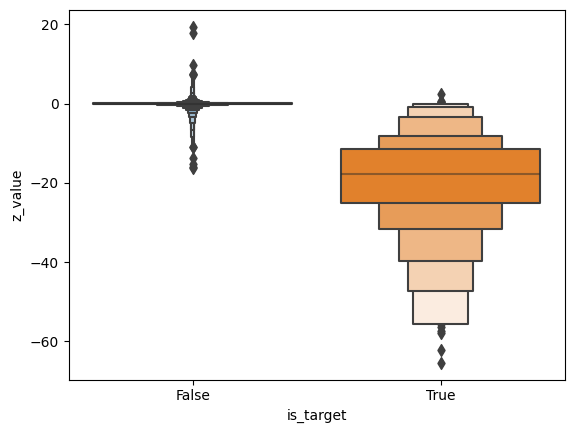

In [36]:
sns.boxenplot(element_effects, x="is_target", y="z_value", scale="area")

In [37]:
element_effects.query("p_value<0.001")['is_target'].mean()

# element_effects['is_target'].sum()
# element_effects

0.7571115973741794

In [38]:
guide_effect_values = model.module.guide.median()["guide_efficacy"]
# i2, j2 = model.module.guide_by_element_idx.detach().cpu().numpy().astype(int)

guide_effects = pd.DataFrame(
    {
        "value": guide_effect_values.squeeze(),
        "guide": pert_ids,
        # "element": [element_ids[idx] for idx in j2],
    }
)
guide_effects.sort_values("value")


,value,guide
583,0.017177,SLC25A39_TSS|2
601,0.017355,SRP14_TSS|2
384,0.026794,NDUFB7_TSS|1
462,0.038605,PPP1R11_TSS|1
460,0.043812,PPM1G_TSS|1
...,...,...
354,0.701113,MSN_TSS|1
511,0.720514,RHAG_TSS|1
604,0.725038,SSR3_TSS|1
83,0.754880,CHCHD10_TSS|1


<Axes: >

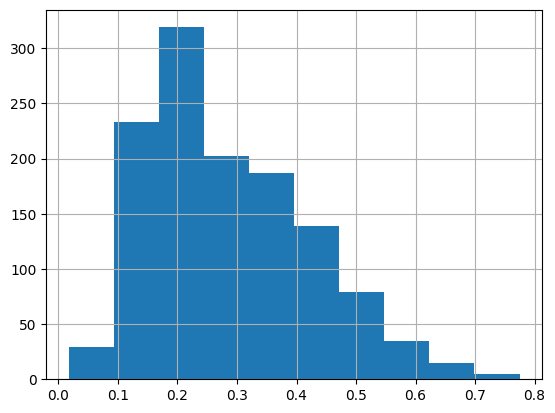

In [39]:
guide_effects['value'].hist()

In [40]:
# guide_effects.groupby("element")["value"].aggregate(["min", "max","count"]).assign(
#     range=lambda x: x["min"] - x["max"]
# ).sort_values("range")


In [41]:
# i, j = model.module.guide_by_element.indices().numpy()
# guide_by_element = coo_matrix((model.module.guide_by_element.values().numpy(), (i,j))) 

# q_mu = guide_by_element @ loc1 + loc2
# q_sigma = np.sqrt((guide_by_element @ scale1).power(2) + scale2.power(2))
# # # q_mu, q_sigma =  (loc.detach().cpu().numpy(), scale.detach().cpu().numpy())

# # q_mu, q_sigma = model.module.get_perturbation_effects()
# assert q_mu.shape == q_sigma.shape
# perturb_z_scores = q_mu/q_sigma
# perturb_p_vals=norm.cdf(perturb_z_scores)

In [42]:
# np.isnan(perturb_z_scores).any()


convert matrix into long df of results

In [43]:
# def make_long_df(mat, value_name):
#     return (
#         pd.DataFrame(data=mat, columns=selected_genes, index=selected_guides)
#         .melt(var_name="gene", value_name=value_name, ignore_index=False)
#         .reset_index(names="guide")
#     )

# scpower_df = pd.merge(
#     make_long_df(perturb_z_scores, "z_value"),
#     make_long_df(perturb_p_vals, "p_value")
# )

In [44]:
# scpower_df.sort_values('p_value')
sceptre_df=sceptre_df.assign(element=lambda x: x['guide'].str.split(r'|', regex=False, expand=True)[0])


In [45]:
merge_df = element_effects.merge(sceptre_df, how="inner", on=["element", "gene"])

if not smoke_test:
    assert len(merge_df)==len(sceptre_df)

# len(merge_df)
# # merge_df.sort_values("SCEPTRE_p_value")

## Visualize hits



In [46]:
from sklearn.linear_model import LinearRegression

reg_x=(merge_df[["z_value"]].values)
reg_y=(merge_df[["SCEPTRE_z_value"]].values)
reg = LinearRegression(fit_intercept=False).fit(reg_x, reg_y)
print("slope:", reg.coef_[0,0])
print("R^2:", reg.score(reg_x, reg_y))


slope: 0.6296541
R^2: 0.8262036842750641


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be r

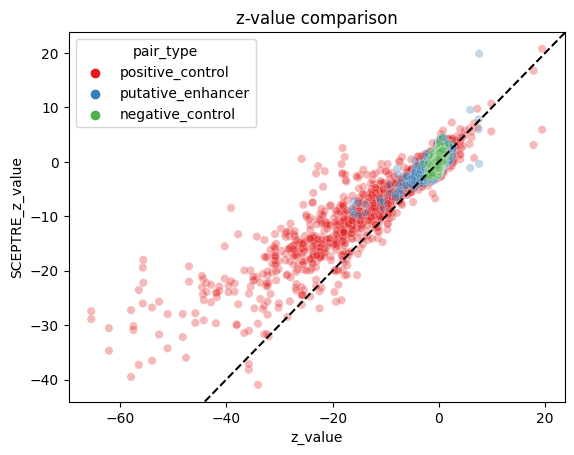

In [47]:
plt.title("z-value comparison")
sns.scatterplot(merge_df, x='z_value', y='SCEPTRE_z_value', hue='pair_type', alpha=0.3, palette='Set1')
plt.axline((0, 0), slope=1, c='black', linestyle='dashed')
plt.show()


In [48]:
# factor0 = model.module.guide.median()["factor_x_gene"][0,:]
# top_genes=factor0.abs().numpy().argsort()[-10:]
# mdata['rna'].var_names[top_genes]

## Interactive data visualization
Need to subset and clip the data so that we can plot interactively

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be r

(1e-21, 2)

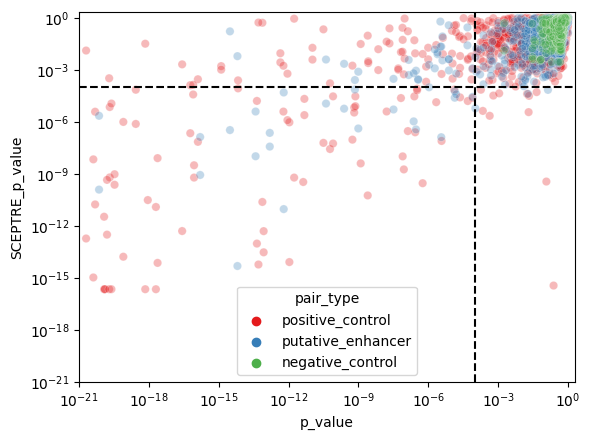

In [49]:
# merge_df['p_value'] = np.maximum(merge_df['p_value'], min_p_value)

sns.scatterplot(merge_df, x="p_value", y="SCEPTRE_p_value", hue="pair_type", alpha=0.3, palette="Set1")
# plt.axline((0, 0), slope=1, c='black', linestyle='dashed')
plt.axhline(1e-4, c='black', linestyle='dashed')
plt.axvline(1e-4,  c='black', linestyle='dashed')

plt.loglog()
# plt.legend()
plt.xlim(1e-21, 2)
plt.ylim(1e-21, 2)

In [50]:
min_p_value = 1e-100

subset_results = merge_df.query("p_value<0.01 or SCEPTRE_p_value < 0.01").copy()
# subset_results = merge_df.query("p_value<1e-5")
subset_results['p_value'] = np.maximum(subset_results['p_value'], min_p_value)
subset_results

,loc,scale,element,gene,z_value,p_value,is_target,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change
20,-1.717627,0.068154,ACTB_TSS,ACTB,-25.202160,1.000000e-100,True,ACTB_TSS|1,positive_control,2.220446e-16,-18.059480,-0.430690
21,-1.717627,0.068154,ACTB_TSS,ACTB,-25.202160,1.000000e-100,True,ACTB_TSS|2,positive_control,2.220446e-16,-14.730568,-0.314530
34,-0.104966,0.071053,ACTB_TSS,EIF2AK1,-1.477280,6.980028e-02,False,ACTB_TSS|1,positive_control,6.815226e-03,-2.075840,-0.056775
72,-0.123024,0.209150,ACTG1_TSS,BAHCC1,-0.588209,2.781961e-01,False,ACTG1_TSS|1,positive_control,7.964032e-03,-2.169500,-0.647819
76,-3.356561,0.152009,ACTG1_TSS,ACTG1,-22.081278,1.000000e-100,True,ACTG1_TSS|1,positive_control,2.220446e-16,-13.778191,-0.795850
...,...,...,...,...,...,...,...,...,...,...,...,...
21893,-0.346154,0.225545,scrambled_16,MCL1,-1.534741,6.242370e-02,False,scrambled_16|2,negative_control,3.247467e-03,-2.478102,-0.279694
21921,-0.953658,0.641540,scrambled_17,LINC00682,-1.486514,6.857155e-02,False,scrambled_17|2,negative_control,3.841884e-03,-2.391648,-0.945072
22049,-0.014415,0.168057,scrambled_23,ARHGEF37,-0.085777,4.658218e-01,False,scrambled_23|2,negative_control,2.748291e-03,-2.389295,-2.091435
22091,-0.183760,0.152370,scrambled_25,GMPS,-1.206011,1.139067e-01,False,scrambled_25|2,negative_control,8.834578e-03,-2.420735,-0.190482


In [51]:
pos_controls = merge_df.query("pair_type=='positive_control'")
pos_controls=pos_controls[~pos_controls['gene'].str.contains("-AS")] # remove alt start sites
pos_controls=pos_controls.assign(
    perturbo_rank=lambda x: x.groupby('guide')['p_value'].rank(),
    perturbo_p_rank=lambda x: x.groupby('guide')['z_value'].rank(),
    SCEPTRE_p_rank=lambda x: x.groupby('guide')['SCEPTRE_p_value'].rank(),
    SCEPTRE_z_rank=lambda x: x.groupby('guide')['SCEPTRE_z_value'].rank()
)
pos_controls

,loc,scale,element,gene,z_value,p_value,is_target,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change,perturbo_rank,perturbo_p_rank,SCEPTRE_p_rank,SCEPTRE_z_rank
0,0.019316,0.151948,ACTB_TSS,Y_RNA,0.127121,5.505779e-01,False,ACTB_TSS|1,positive_control,9.407069e-01,1.632176,0.469126,16.0,16.0,20.0,20.0
1,0.019316,0.151948,ACTB_TSS,Y_RNA,0.127121,5.505779e-01,False,ACTB_TSS|2,positive_control,5.110618e-01,-0.108080,-0.036663,16.0,16.0,11.0,9.0
2,-0.049500,0.112770,ACTB_TSS,FOXK1,-0.438944,3.303512e-01,False,ACTB_TSS|1,positive_control,1.536294e-01,-0.992648,-0.088097,9.0,9.0,6.0,8.0
3,-0.049500,0.112770,ACTB_TSS,FOXK1,-0.438944,3.303512e-01,False,ACTB_TSS|2,positive_control,4.333304e-01,-0.184539,-0.015502,9.0,9.0,8.0,8.0
4,-0.093943,0.148004,ACTB_TSS,AP5Z1,-0.634732,2.628017e-01,False,ACTB_TSS|1,positive_control,1.235624e-01,-1.010549,-0.119240,5.0,5.0,5.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13733,0.211958,0.210944,ZRANB2_TSS,CTH,1.004807,8.425052e-01,False,ZRANB2_TSS|2,positive_control,9.327070e-01,1.796781,0.294750,8.0,8.0,8.0,8.0
13734,-0.011596,0.087926,ZRANB2_TSS,PTGER3,-0.131888,4.475365e-01,False,ZRANB2_TSS|1,positive_control,6.381494e-01,0.154986,0.006930,4.0,4.0,6.0,6.0
13735,-0.011596,0.087926,ZRANB2_TSS,PTGER3,-0.131888,4.475365e-01,False,ZRANB2_TSS|2,positive_control,3.728405e-01,-0.504247,-0.050689,4.0,4.0,3.0,3.0
13736,-1.721148,0.127230,ZRANB2_TSS,ZRANB2,-13.527892,5.352467e-42,True,ZRANB2_TSS|1,positive_control,2.220446e-16,-11.648026,-0.955711,1.0,1.0,1.0,1.0


In [52]:
target_pairs = pos_controls.query('is_target')
print("our accuracy: "+str(len(target_pairs.query('perturbo_rank==1'))/len(target_pairs)))
print("SCEPTRE accuracy: "+str(len(target_pairs.query('SCEPTRE_z_rank==1'))/len(target_pairs)))
print("SCEPTRE accuracy: "+str(len(target_pairs.query('SCEPTRE_p_rank==1'))/len(target_pairs)))

our accuracy: 0.9521857923497268
SCEPTRE accuracy: 0.924863387978142
SCEPTRE accuracy: 0.9153005464480874


In [53]:
# target_pairs.query('perturbo_rank==1 and SCEPTRE_z_rank>=2')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]
target_pairs.query('perturbo_rank==1 and SCEPTRE_p_rank>1')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]
# target_pairs.query('perturbo_rank>1 and SCEPTRE_p_rank==1')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]

,guide,gene,perturbo_rank,SCEPTRE_p_rank
189,ACYP1_TSS|2,ACYP1,1.0,6.0
573,AZIN1_TSS|2,AZIN1,1.0,2.0
672,BANF1_TSS|1,BANF1,1.0,9.0
2159,COMT_TSS|1,COMT,1.0,1.5
2386,CSNK1A1_TSS|2,CSNK1A1,1.0,7.0
2968,EEF1A1_TSS|2,EEF1A1,1.0,3.0
3386,EIF4A3_TSS|2,EIF4A3,1.0,2.0
4122,GADD45A_TSS|2,GADD45A,1.0,4.0
4174,GATA2_TSS|2,GATA2,1.0,4.0
4944,ID1_TSS|2,ID1,1.0,3.0


In [54]:
target_pairs.query('perturbo_rank>1 and SCEPTRE_p_rank==1')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]

,guide,gene,perturbo_rank,SCEPTRE_p_rank
5011,ID3_TSS|1,ID3,2.0,1.0
5012,ID3_TSS|2,ID3,2.0,1.0
5894,MAN1A1_TSS|2,MAN1A1,2.0,1.0
6775,MTRNR2L8_TSS|1,MTRNR2L8,2.0,1.0
9867,RPL21_TSS|2,RPL21,2.0,1.0
11537,TAF12_TSS|2,TAF12,2.0,1.0


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and

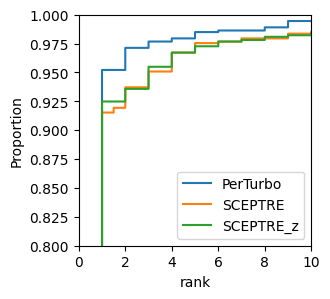

In [55]:
with plt.rc_context({"figure.figsize": [3,3]}):

  sns.ecdfplot(pos_controls.query('is_target'), x='perturbo_rank',stat="proportion", label="PerTurbo")
  sns.ecdfplot(pos_controls.query('is_target'), x='SCEPTRE_p_rank',stat="proportion", label="SCEPTRE")
  sns.ecdfplot(pos_controls.query('is_target'), x='SCEPTRE_z_rank',stat="proportion", label="SCEPTRE_z")
  plt.legend()
  # plt.title("eCDF")
  # plt.semilogy()
  plt.xlabel("rank")
  plt.xlim([0,10])
  plt.ylim(0.8, 1)
  plt.show()

0.95620288897937 0.9234061231976527


Text(0.5, 1.0, 'perturbo vs. SCEPTRE p-values')

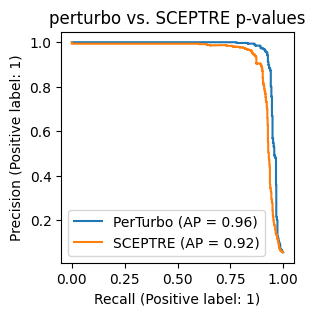

In [61]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, average_precision_score, precision_recall_curve

with plt.rc_context({"figure.figsize": [3,3]}):
  roc = PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], 1-pos_controls['z_value'], name="PerTurbo")
  PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], 1-pos_controls['SCEPTRE_p_value'], ax=roc.ax_, name="SCEPTRE")

precision, recall, threshold = precision_recall_curve(pos_controls['is_target'], 1-pos_controls['z_value'])
score1=average_precision_score(pos_controls['is_target'], 1-pos_controls['z_value'])
score2=average_precision_score(pos_controls['is_target'], 1-pos_controls['SCEPTRE_p_value'])
print(score1, score2)
plt.title("perturbo vs. SCEPTRE p-values")
# svc_disp = RocCurveDisplay.from_estimator(X_test, y_test)
# rfc_disp = RocCurveDisplay.from_estimator(X_test, y_test, ax=svc_disp.ax_)


0.95620288897937 0.9304176453265475


Text(0.5, 1.0, 'z-values')

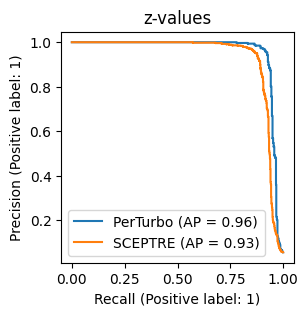

In [57]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, average_precision_score, precision_recall_curve

with plt.rc_context({"figure.figsize": [3,3]}):
  roc = PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], -pos_controls['z_value'], name="PerTurbo")
  PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], -pos_controls['SCEPTRE_z_value'], ax=roc.ax_, name="SCEPTRE")


precision, recall, threshold = precision_recall_curve(pos_controls['is_target'], 1-pos_controls['z_value'])
score1=average_precision_score(pos_controls['is_target'], -pos_controls['z_value'])
score2=average_precision_score(pos_controls['is_target'], -pos_controls['SCEPTRE_z_value'])
print(score1, score2)
plt.title('z-values')
# plt.title()
# svc_disp = RocCurveDisplay.from_estimator(X_test, y_test)
# rfc_disp = RocCurveDisplay.from_estimator(X_test, y_test, ax=svc_disp.ax_)


In [58]:
# len(merge_df)
# len(sceptre_df)
# model.module.guide.median()['element_x_factor'].min()
loc, scale = model.module.guide._get_loc_and_scale("factor_x_gene")
factor_x_gene_z_score = (loc/scale).detach().numpy()

factor_x_gene_df = pd.DataFrame(
    factor_x_gene_z_score,
    columns = mdata['rna'].var_names
)
# sns.heatmap(factor_x_gene_df, cmap="vlag", center=0, vmin=-5, vmax=5)

sns.clustermap(factor_x_gene_df.T, cmap="vlag", center=0, vmin=-5, vmax=5, metric="cosine", figsize=(16,16))


AttributeError: 'PyroModule' object has no attribute 'factor_x_gene'

In [ ]:
# factor_x_gene_df.loc[5].sort_values()[-20:].index

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


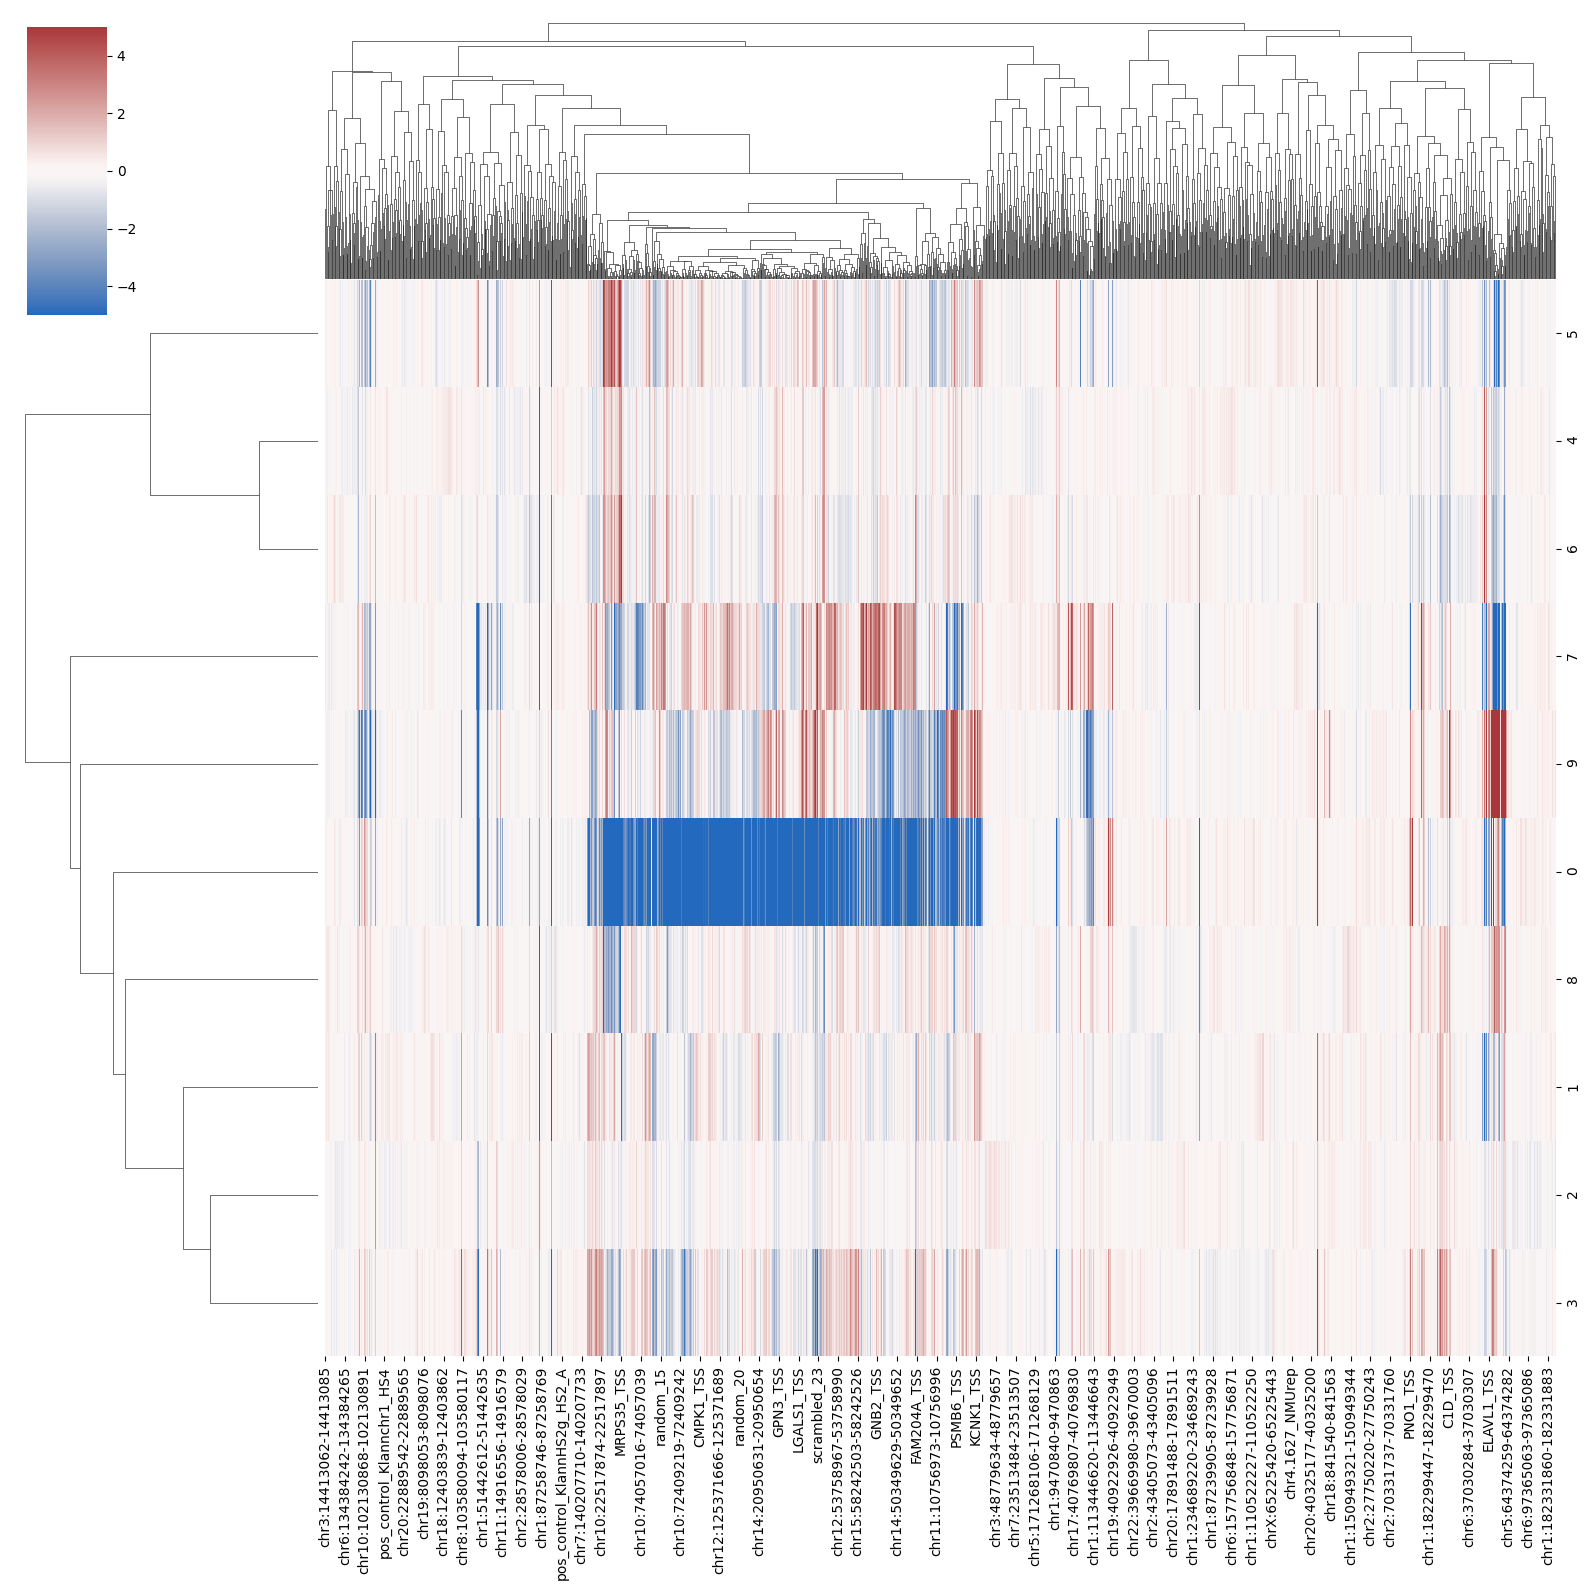

In [ ]:
loc, scale = model.module.guide._get_loc_and_scale("element_x_factor")
element_x_factor_z_score = (loc/scale).detach().numpy()

element_x_factor_df = pd.DataFrame(
    element_x_factor_z_score,
    index= mdata['grna'].varm['element_targeted'].columns
)
# sns.heatmap(element_x_factor_df, cmap="vlag", center=0)

sns.clustermap(element_x_factor_df.T, cmap="vlag", center=0, vmin=-5, vmax=5, metric="cosine",  figsize=(16,16))

# biggest_gene = model.module.guide.median()['factor_x_gene'][biggest_factor_idx, :].argmax()
# biggest_element = model.module.guide.median()['element_x_factor'][:, biggest_factor_idx].argmax()

# elements =  mdata['grna'].varm['element_targeted'].columns
# genes = mdata['rna'].var_names

# plt.bar(x=values[:10].numpy(), height=)

# mdata['grna'].varm['element_targeted'].columns[int(biggest_element)]
# mdata['rna'].var_names[int(biggest_gene)]

In [ ]:
# plt.plot(np.log(threshold), precision[:-1])

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# guide_1 = f"{plot_gene}_TSS|1"
# guide_2 = f"{plot_gene}_TSS|2"

gene_select = widgets.Dropdown(
    options=sorted(mdata['rna'].var_names),
    value=mdata['rna'].var_names[0],
    # rows=10,
    description='Gene',
    disabled=False
)


guide_select = widgets.Dropdown(
    options=sorted(mdata['grna'].var_names),
    value=mdata['grna'].var_names[0],
    # rows=10,
    description='Guide',
    disabled=False
)

display(gene_select, guide_select)

ModuleNotFoundError: No module named 'ipywidgets'

In [ ]:
# import scanpy as sc

# plot_guides = ['TMED10_TSS|1','TMED10_TSS|2']
# plot_genes = ['TMED10', 'KDELR2','KDELR3','SEC13', 'YIF1A', 'CALU', 'YIPF2', 'SDF2L1', 'MANF']

plot_genes = [gene_select.value]
plot_guides = [guide_select.value]


counts_df = mdata["rna"][:, plot_genes].to_df()
guide_obs = mdata["grna"][:, plot_guides].X.sum(axis=1).copy().astype(bool)
counts_df['guide_obs']=guide_obs


# mdata['rna'].obs['TMED10_TSS'] = guide_obs
# mdata['rna'].obs['TMED10_TSS']=mdata['rna'].obs['TMED10_TSS'].astype("category")
# # mdata['rna'].raw = mdata['rna']
# # sc.pp.normalize_total(mdata['rna'])
# with plt.rc_context({'figure.dpi':200}):
#   sc.pl.dotplot(mdata['rna'], plot_genes, groupby='TMED10_TSS', title='TMED10_TSS')

NameError: name 'gene_select' is not defined

In [ ]:
# plot_gene = gene_select.value
# plot_guide = guide_select.value
# print(plot_gene, plot_guide)

# plot_df = pd.DataFrame({"count": counts, "has_guide": guide_obs})
plot_df = counts_df.melt(id_vars='guide_obs',var_name='gene',value_name='count')
g = sns.FacetGrid(plot_df, col="gene", row="guide_obs",sharey=False)
g.map_dataframe(
    sns.histplot,
    x="count", binwidth=1,
    hue_order=[False,True],
    # log_scale=[False,True]
)
plt.xlim(0,50)
# plt.semilogy()

# sns.histplot(
#     plot_df.query('has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# plt.show()
# sns.histplot(
#     plot_df.query('not has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# # plt.xlim(0, 50)
# g.title(f"gene: {plot_gene}, guide: {plot_guide}")
# plt.show()



NameError: name 'counts_df' is not defined

In [ ]:
!pwd

/Users/ljb80/Projects/perturbo/reproducibility


In [ ]:
import altair as alt

alt.Chart(subset_results).mark_point().encode(
  x='z_value',
  y='SCEPTRE_z_value',
  color='is_target',
  tooltip=['guide','gene', 'z_value', 'SCEPTRE_z_value'] 
).interactive()


ModuleNotFoundError: No module named 'altair'

#### scpower_df.to_csv(f"{data_dir}/scpower_results.csv")